# Assignment 06 — CNN for Tomato Disease Classification

## Problem Statement

Design and implement a Convolutional Neural Network (CNN) for image classification using the Tomato or Soybean disease dataset.

## Objective

Develop a CNN-based image classifier for tomato leaf disease recognition and evaluate its performance using training and validation accuracy and loss.

The submitted practical uses a tomato disease dataset organized into separate training and validation folders with 10 classes.

In [5]:
!unzip -q "tomato (2).zip"

replace tomato/cnn_train.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## 1. Import Libraries and Configuration

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 15
TRAIN_DIR = "tomato/train"
VAL_DIR = "tomato/val"

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load the Tomato Disease Dataset

The dataset follows the Keras class-folder structure:

```text
tomato/
├── train/
│   ├── Tomato_Bacterial_spot/
│   ├── Tomato_Early_blight/
│   ├── Tomato_healthy/
│   ├── Tomato_Late_blight/
│   ├── Tomato_Leaf_Mold/
│   ├── Tomato_Septoria_leaf_spot/
│   ├── Tomato_Spider_mites Two-spotted_spider_mite/
│   ├── Tomato_Target_Spot/
│   ├── Tomato_Tomato_mosaic_virus/
│   └── Tomato_Tomato_Yellow_Leaf_Curl_Virus/
└── val/
    └── same class folders
```

The practical sheet shows this train/validation organization on page 1.

In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    shuffle=True, seed=42
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Number of classes: 10


## 3. Visualize Sample Images

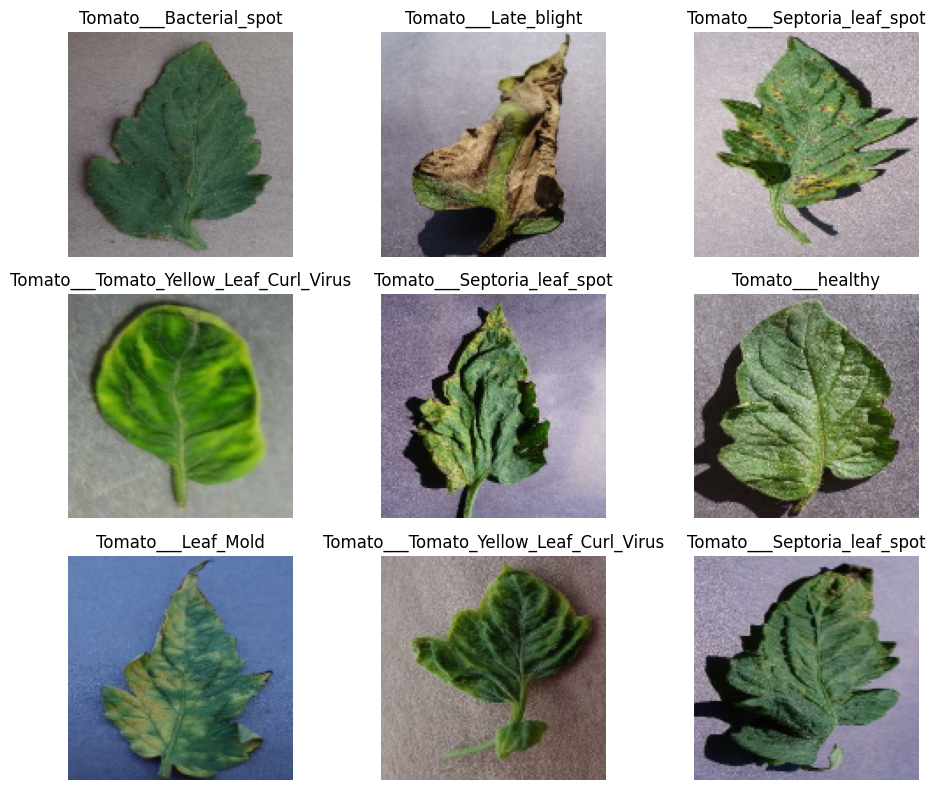

In [8]:
plt.figure(figsize=(10, 8))
for images, labels in train_dataset.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Build the CNN Model

The submitted model uses three convolutional blocks with 32, 64 and 128 filters, followed by Flatten, Dense(128), Dropout(0.5), and a 10-class softmax output. Its recorded summary contains 3,305,930 trainable parameters.

In [9]:
model = models.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### CNN Architecture

```text
Input (128×128×3)
      ↓
Rescaling (1/255)
      ↓
Conv2D 32 → MaxPooling
      ↓
Conv2D 64 → MaxPooling
      ↓
Conv2D 128 → MaxPooling
      ↓
Flatten
      ↓
Dense 128 → Dropout 0.5
      ↓
Softmax (10 classes)
```

## 5. Compile the Model

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 6. Train the CNN

In [11]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.3823 - loss: 1.7130 - val_accuracy: 0.6810 - val_loss: 0.9621
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.6631 - loss: 0.9783 - val_accuracy: 0.7450 - val_loss: 0.7478
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.7414 - loss: 0.7587 - val_accuracy: 0.7940 - val_loss: 0.6118
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7805 - loss: 0.6258 - val_accuracy: 0.8300 - val_loss: 0.5705
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8180 - loss: 0.5189 - val_accuracy: 0.8370 - val_loss: 0.5212
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8369 - loss: 0.4618 - val_accuracy: 0.8380 - val_loss: 0.4967
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8530 - loss: 0.4170 - val_accuracy: 0.8020 - val_loss: 0.6159
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8721 - loss: 0.3647 - val_

## 7. Evaluate the Model

The submitted practical trained for 15 epochs. Its final recorded validation result was **85.50% accuracy** with **0.5064 validation loss**.

In [12]:
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=1)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4%}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8500 - loss: 0.5913
Validation Loss: 0.5913
Validation Accuracy: 85.0000%


## 8. Training vs Validation Accuracy

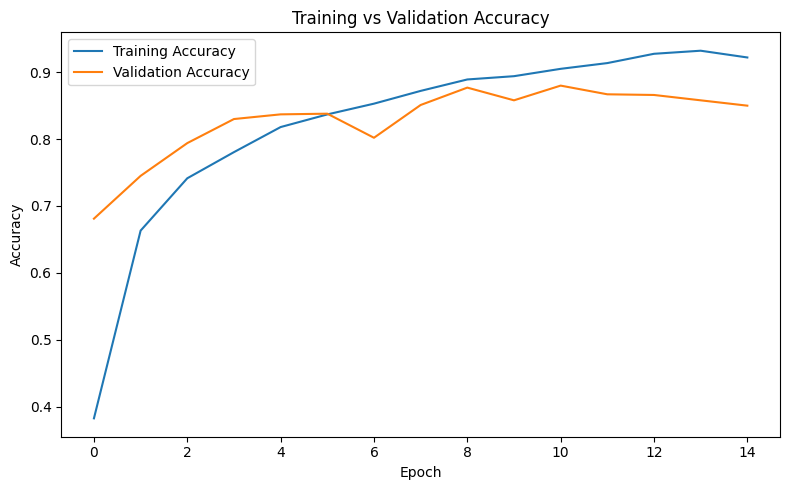

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Training vs Validation Loss

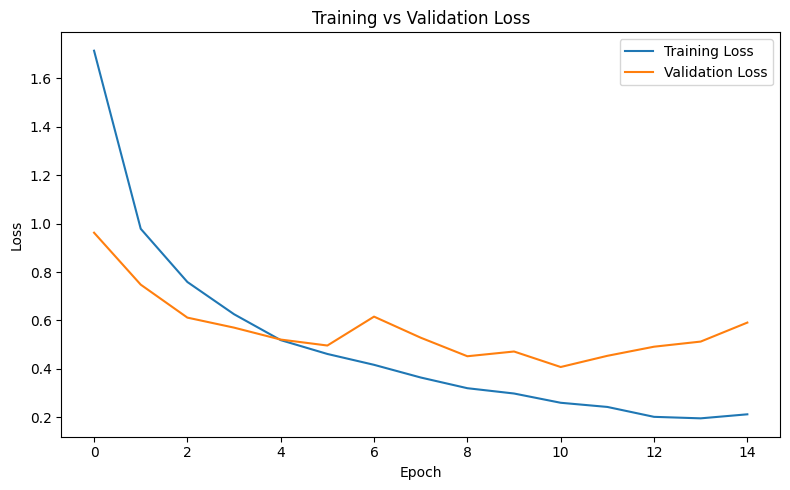

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Save the Trained Model

In [15]:
MODEL_PATH = "tomato_disease_cnn.keras"
model.save(MODEL_PATH)
print("Model saved successfully:", MODEL_PATH)

Model saved successfully: tomato_disease_cnn.keras


## 11. Conclusion

A three-block CNN was implemented for 10-class tomato disease classification. The submitted experiment achieved **85.50% validation accuracy** with **0.5064 validation loss** after 15 epochs.

The accuracy and loss curves are also useful for examining generalization: training performance improves steadily while validation performance becomes more variable during later epochs.